## Import Library

In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Load Dataset

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url)
print(df.head())
print("="*20)
print(df.tail())

                      Date    Close    Volume USDT        RSI  MACD_Hist  \
0  2017-09-21 09:00:00.000  3860.00   74434.891166  49.192454 -48.279697   
1  2017-09-21 10:00:00.000  3871.48   44687.318944  49.233202 -47.780476   
2  2017-09-21 11:00:00.000  3864.95   80546.171672  49.210685 -47.308061   
3  2017-09-21 12:00:00.000  3858.08   90331.531390  49.186948 -46.863233   
4  2017-09-21 13:00:00.000  3856.67  103405.818040  49.182064 -46.425379   

         ATR     KAMAO  
0  88.054720  2.495591  
1  87.996283  2.616710  
2  87.897128  2.532239  
3  87.720856  2.447245  
4  87.578086  2.424654  
                      Date     Close   Volume USDT        RSI   MACD_Hist  \
53145  2023-10-19 19:00:00  28750.75  2.984059e+07  53.630054  109.926882   
53146  2023-10-19 20:00:00  28715.38  4.997623e+07  53.531282  111.721905   
53147  2023-10-19 21:00:00  28604.09  3.205666e+07  53.221944  113.055031   
53148  2023-10-19 22:00:00  28649.65  2.200420e+07  53.332673  114.513131   
53149  2

In [4]:
print(df.info())
print(f"Missing Value\n{df.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB
None
Missing Value
Date           0
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64


## Pre Processing

In [6]:
try:
  df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
except TypeError:
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df.dropna(subset=['Date'])
df = df.sort_values('Date').set_index('Date')
df = df[~df.index.duplicated(keep='first')]

In [8]:
for i in df.columns:
  df[i]=pd.to_numeric(df[i], errors='coerce')
print(df.isna().sum())

Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64


In [13]:
MAX_ROWS = 15000

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.tail(MAX_ROWS).copy()

print('Shape data eksperimen:', df.shape)
print('Rentang tanggal:', df.index.min(), 'sampai', df.index.max())

Shape data eksperimen: (15000, 6)
Rentang tanggal: 2022-02-01 22:00:00 sampai 2023-10-19 23:00:00


## EDA + Heatmap

In [14]:
print(f"Analisis Deskriptif \n {df.describe()}")

Analisis Deskriptif 
               Close   Volume USDT           RSI     MACD_Hist           ATR  \
count  15000.000000  1.500000e+04  15000.000000  15000.000000  15000.000000   
mean   26718.431741  1.306602e+08     49.848538     18.077114    210.707234   
std     7468.861227  1.469708e+08      3.103627    324.288824    106.719690   
min    15649.520000  0.000000e+00     40.882450  -1048.229892     55.975843   
25%    20769.697500  3.714671e+07     47.935837   -152.115863    129.831907   
50%    26309.340000  8.418789e+07     49.390664     19.717947    175.759526   
75%    29741.705000  1.708560e+08     51.626323    178.682088    271.929869   
max    47970.990000  3.005634e+09     64.657108   1207.432851    477.916357   

              KAMAO  
count  15000.000000  
mean      -0.192528  
std        5.410226  
min      -27.198601  
25%       -2.971573  
50%       -0.580157  
75%        2.593031  
max       39.740297  


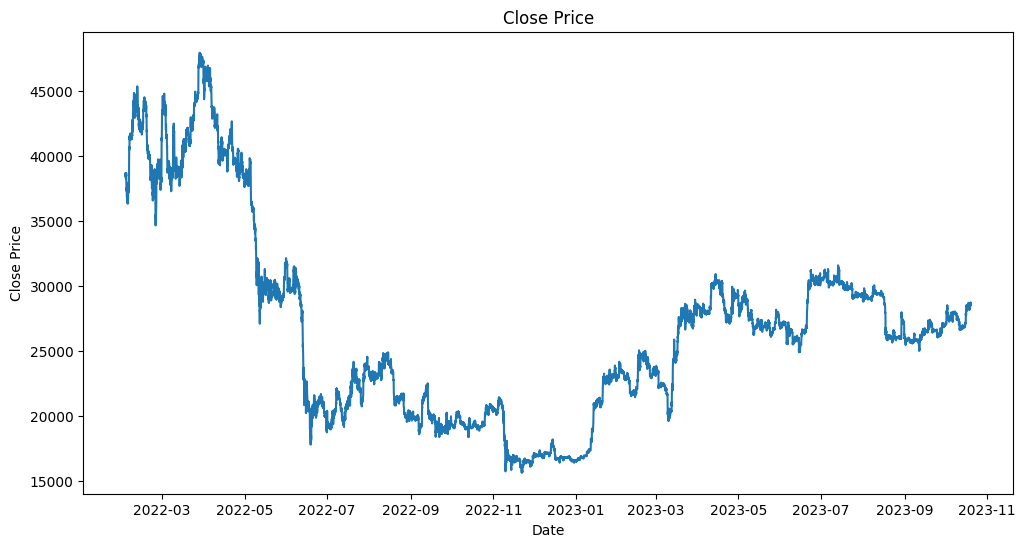

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df['Close'])
plt.title('Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

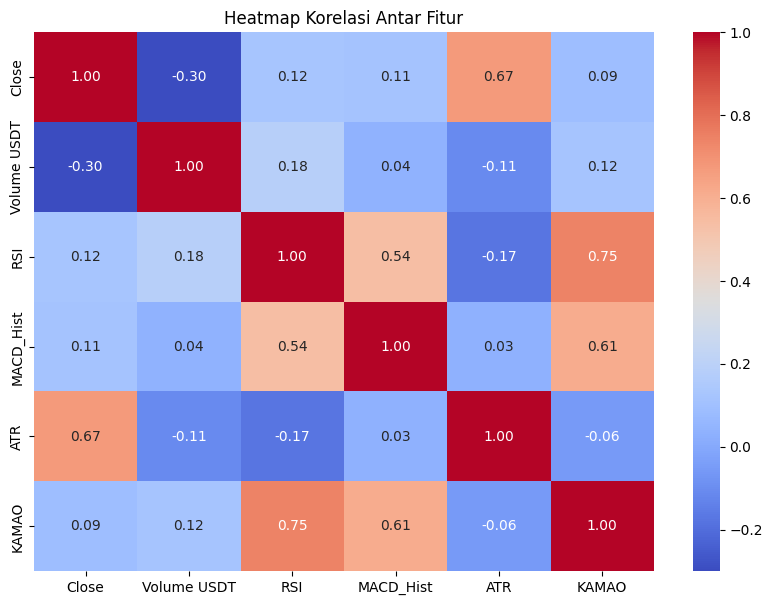

In [17]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## EDA ADF Test

In [18]:
def adf_test(series,name="series"):
    result = adfuller(series, autolag='AIC')
    print("ADF Test pada kolom:",name)
    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data stasioner")
    else:
        print("Data tidak stasioner")
adf_test(df['Close'],'Close')

ADF Test pada kolom: Close
ADF Test Results:
ADF Statistic: -1.6645150713593535
p-value: 0.44948182189306574
Data tidak stasioner


## EDA Decomposisi

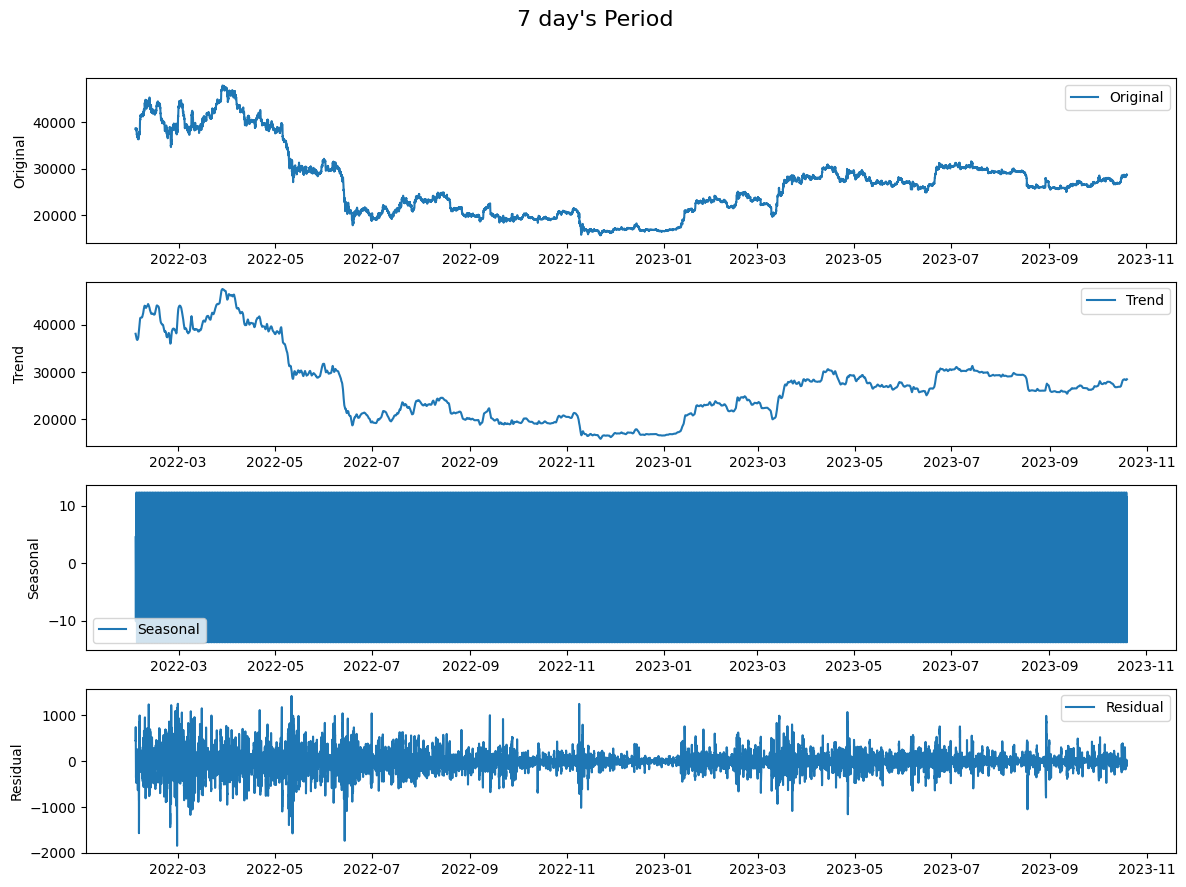

In [19]:
decomposition = seasonal_decompose(df['Close'], period=24, model='additive')

components = {
    'Original': df['Close'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}

plt.figure(figsize=(12, 9))
plt.suptitle("7 day's Period", fontsize=16)

for i, (title, series) in enumerate(components.items(), start=1):
    plt.subplot(4, 1, i)
    plt.plot(df.index, series, label=title)
    plt.legend(loc='best')
    plt.ylabel(title)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## ACF, PACF dan Window Size

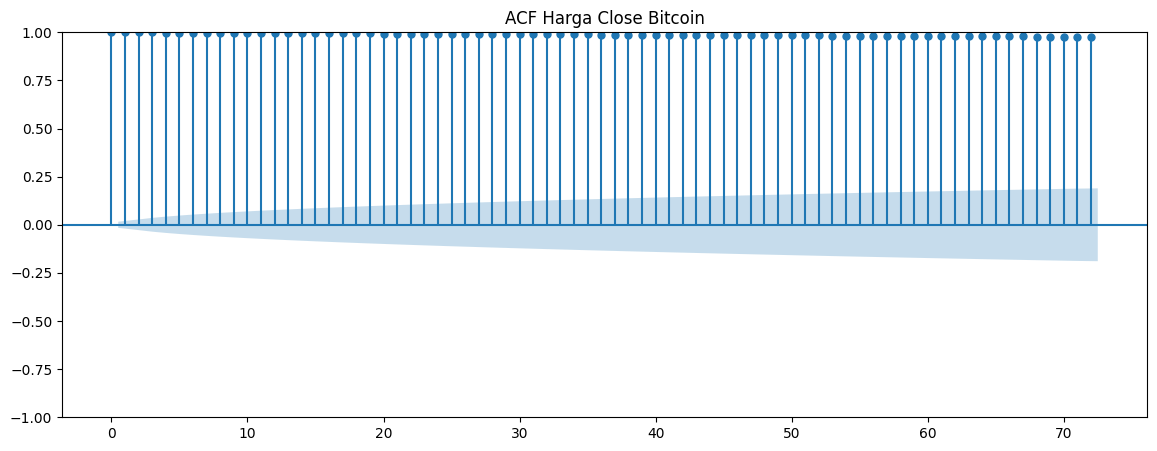

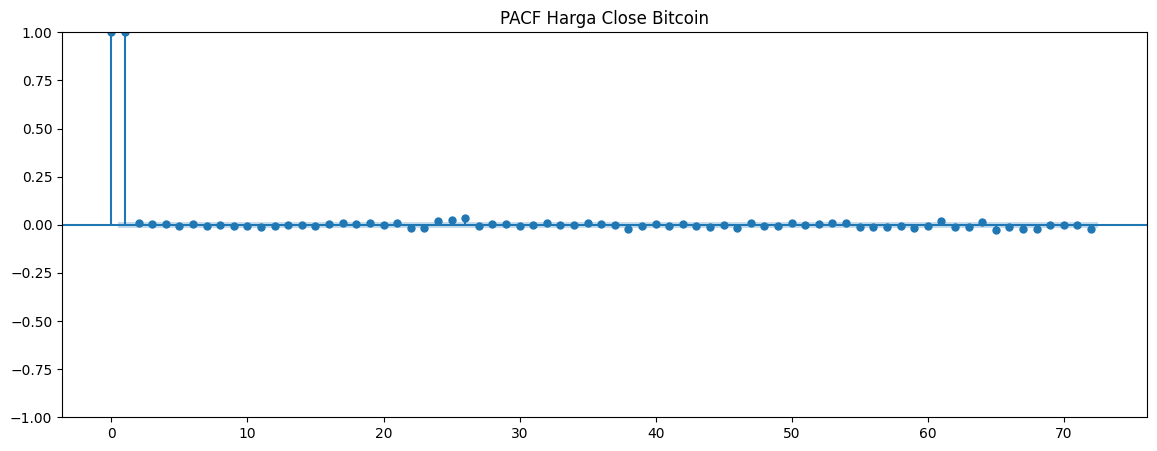

Threshold ACF kasar: 0.016003
Lag signifikan terakhir: 72
WINDOW_SIZE final: 72 jam
HORIZON: 24 jam


In [21]:
target_for_lag = df['Close'].dropna()
max_lag = 72

plt.figure(figsize=(14, 5))
plot_acf(target_for_lag, lags=max_lag, ax=plt.gca())
plt.title('ACF Harga Close Bitcoin')
plt.show()

plt.figure(figsize=(14, 5))
plot_pacf(target_for_lag, lags=max_lag, ax=plt.gca(), method='ywm')
plt.title('PACF Harga Close Bitcoin')
plt.show()

acf_values = acf(target_for_lag, nlags=max_lag, fft=True)
conf = 1.96 / np.sqrt(len(target_for_lag))
significant_lags = np.where(np.abs(acf_values[1:]) > conf)[0] + 1
last_sig_lag = int(significant_lags[-1]) if len(significant_lags) > 0 else 48

WINDOW_SIZE = int(np.clip(last_sig_lag, 48, 72))
HORIZON = 24
print(f'Threshold ACF kasar: {conf:.6f}')
print(f'Lag signifikan terakhir: {last_sig_lag}')
print(f'WINDOW_SIZE final: {WINDOW_SIZE} jam')
print(f'HORIZON: {HORIZON} jam')

## Feature Engineeri (Rolling Stats dan Time-Based Feature)

In [25]:
data = df[['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']].copy()
data['Close_roll_mean_24'] = data['Close'].rolling(window=24, min_periods=24).mean()
data['Close_roll_std_24'] = data['Close'].rolling(window=24, min_periods=24).std()
data['Close_roll_max_24'] = data['Close'].rolling(window=24, min_periods=24).max()
data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
data['dayofweek_sin'] = np.sin(2 * np.pi * data.index.dayofweek / 7)
data['dayofweek_cos'] = np.cos(2 * np.pi * data.index.dayofweek / 7)
data = data.dropna()

In [28]:
feature_cols = list(data.columns)
target_index = feature_cols.index('Close')
print('Jumlah fitur akhir:', len(feature_cols))
print('Daftar fitur:', feature_cols)
print('Target index:', target_index)
print(data.head())

Jumlah fitur akhir: 13
Daftar fitur: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'Close_roll_mean_24', 'Close_roll_std_24', 'Close_roll_max_24', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos']
Target index: 0
                        Close   Volume USDT        RSI   MACD_Hist  \
Date                                                                 
2022-02-02 21:00:00  36922.51  1.276321e+08  47.626765  423.235492   
2022-02-02 22:00:00  37006.93  5.692172e+07  47.690931  421.017141   
2022-02-02 23:00:00  36896.36  5.630153e+07  47.614298  418.434294   
2022-02-03 00:00:00  36878.39  6.690306e+07  47.601829  415.835504   
2022-02-03 01:00:00  36845.52  4.082134e+07  47.578972  413.166369   

                            ATR     KAMAO  Close_roll_mean_24  \
Date                                                            
2022-02-02 21:00:00  438.388920 -1.793478        38148.698333   
2022-02-02 22:00:00  438.246393 -1.584739        38078.255833   
2022-02-02 23

## Split Data sebelum melakukan Transformasi Scalling data

In [29]:
n = len(data)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()
print('Train:', train_df.shape, 'Val:', val_df.shape, 'Test:', test_df.shape)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)
print('Scaling selesai. Scaler hanya fit pada train.')

Train: (11981, 13) Val: (1498, 13) Test: (1498, 13)
Scaling selesai. Scaler hanya fit pada train.


## Windowing dengan tf.data.dataset

In [32]:
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE
def make_multivariate_windows(window):
    # Encoder input akan berisi SEMUA FITUR dari masa lalu.
    encoder_input = window[:-HORIZON]

    # Decoder target HANYA akan berisi fitur yang ingin kita prediksi (misalnya 'Price').
    # Ambil semua baris di HORIZON, tapi hanya kolom ke-0 (Price)
    decoder_target = window[-HORIZON:, 0:1]
    start_token = encoder_input[-1:, 0:1]

    # Gabungkan start token dengan target masa depan (tanpa nilai terakhir)
    decoder_input = tf.concat([start_token, decoder_target[:-1]], axis=0)
    return (encoder_input, decoder_input), decoder_target

In [33]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
def create_multivariate_dataset(array_2d,shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(array_2d.astype(np.float32))
    ds = ds.window(WINDOW_SIZE + HORIZON, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(WINDOW_SIZE + HORIZON))
    ds = ds.map(make_multivariate_windows, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds_multi = create_multivariate_dataset(train_scaled)
val_ds_multi = create_multivariate_dataset(val_scaled)
test_ds_multi = create_multivariate_dataset(test_scaled)

In [35]:
for (enc_x, dec_x), y in train_ds_multi.take(1):
    print('Encoder input:', enc_x.shape)
    print('Decoder input:', dec_x.shape)
    print('Target:', y.shape)

N_FEATURES = train_scaled.shape[1]
print('N_FEATURES:', N_FEATURES)

Encoder input: (128, 72, 13)
Decoder input: (128, 24, 1)
Target: (128, 24, 1)
N_FEATURES: 13


## Custom Layer

In [36]:
class CustomDense(layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(name='kernel', shape=(int(input_shape[-1]), self.units), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='bias', shape=(self.units,), initializer='zeros', trainable=True)

    def call(self, inputs):
        z = tf.matmul(inputs, self.w) + self.b
        return self.activation(z) if self.activation is not None else z

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.units,)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units, 'activation': tf.keras.activations.serialize(self.activation)})
        return cfg

class CustomDropout(layers.Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate
    def call(self, inputs, training=False):
        return tf.nn.dropout(inputs, rate=self.rate) if training else inputs
    def get_config(self):
        cfg = super().get_config(); cfg.update({'rate': self.rate}); return cfg

class CustomLeakyReLU(layers.Layer):
    def __init__(self, alpha=0.1, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
    def call(self, inputs):
        return tf.maximum(inputs, self.alpha * inputs)
    def get_config(self):
        cfg = super().get_config(); cfg.update({'alpha': self.alpha}); return cfg

class RepeatLastTarget(layers.Layer):
    def __init__(self, target_index, horizon, **kwargs):
        super().__init__(**kwargs)
        self.target_index = int(target_index)
        self.horizon = int(horizon)
    def call(self, inputs):
        last_value = inputs[:, -1:, self.target_index:self.target_index + 1]
        return tf.repeat(last_value, repeats=self.horizon, axis=1)
    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.horizon, 1)
    def get_config(self):
        cfg = super().get_config(); cfg.update({'target_index': self.target_index, 'horizon': self.horizon}); return cfg

class ScaleLayer(layers.Layer):
    def __init__(self, scale=0.05, **kwargs):
        super().__init__(**kwargs)
        self.scale = scale
    def call(self, inputs):
        return inputs * self.scale
    def get_config(self):
        cfg = super().get_config(); cfg.update({'scale': self.scale}); return cfg

## Custom MultiHeadAttention

In [37]:
class CustomMultiHeadAttention(layers.Layer):
    def __init__(self, num_heads=2, key_dim=8, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = int(num_heads)
        self.key_dim = int(key_dim)
        self.proj_dim = self.num_heads * self.key_dim
        self.wq = CustomDense(self.proj_dim)
        self.wk = CustomDense(self.proj_dim)
        self.wv = CustomDense(self.proj_dim)
        self.wo = CustomDense(self.proj_dim)

    def split_heads(self, x):
        batch_size = tf.shape(x)[0]
        x = tf.reshape(x, (batch_size, tf.shape(x)[1], self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, query, key, value):
        q = self.split_heads(self.wq(query))
        k = self.split_heads(self.wk(key))
        v = self.split_heads(self.wv(value))
        scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        weights = tf.nn.softmax(scores, axis=-1)
        context = tf.matmul(weights, v)
        context = tf.transpose(context, perm=[0, 2, 1, 3])
        batch_size = tf.shape(context)[0]
        context = tf.reshape(context, (batch_size, tf.shape(context)[1], self.proj_dim))
        return self.wo(context)

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.proj_dim,)

    def get_config(self):
        cfg = super().get_config(); cfg.update({'num_heads': self.num_heads, 'key_dim': self.key_dim}); return cfg

## Baseline ringan + Custom layers

In [38]:
LSTM_UNITS = 48
RESIDUAL_SCALE = 0.05

def build_baseline_lstm(window_size, n_features, horizon):
    encoder_input = layers.Input(shape=(window_size, n_features), name='baseline_encoder_input')
    x = layers.LSTM(LSTM_UNITS, return_sequences=True, name='baseline_lstm_1')(encoder_input)
    attn = CustomMultiHeadAttention(num_heads=2, key_dim=8, name='baseline_custom_mha')(query=x, key=x, value=x)
    x = layers.Concatenate(name='baseline_concat_attention')([x, attn])
    x = layers.LSTM(LSTM_UNITS, return_sequences=False, name='baseline_lstm_2')(x)
    x = CustomDropout(0.1, name='baseline_custom_dropout')(x)
    x = CustomDense(32, name='baseline_custom_dense_1')(x)
    x = CustomLeakyReLU(alpha=0.1, name='baseline_custom_activation')(x)
    residual = CustomDense(horizon, name='baseline_custom_dense_output')(x)
    residual = layers.Reshape((horizon, 1), name='baseline_residual_reshape')(residual)
    residual = ScaleLayer(RESIDUAL_SCALE, name='baseline_residual_scale')(residual)
    last_value = RepeatLastTarget(target_index=target_index, horizon=horizon, name='baseline_repeat_last_close')(encoder_input)
    output = layers.Add(name='baseline_output')([last_value, residual])
    return Model(encoder_input, output, name='model_baseline_LSTM')

baseline_model = build_baseline_lstm(WINDOW_SIZE, N_FEATURES, HORIZON)
baseline_model.summary()

Model: "model_baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ baseline_encoder_i… │ (None, 72, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_lstm_1     │ (None, 72, 48)    │     11,904 │ baseline_encoder… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_custom_mha │ (None, 72, 16)    │      2,624 │ baseline_lstm_1[… │
│ (CustomMultiHeadAt… │                   │            │ baseline_lstm_1[… │
│                     │                   │            │ baseline_lstm_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_concat_at… │ (None, 72, 64)    │          0 │ baseline_lstm_1[… │
│ (Concatenate)       │                   │            │ baseline_custom_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_lstm_2     │ (None, 48)        │     21,696 │ baseline_concat_… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_custom_dr… │ (None, 48)        │          0 │ baseline_lstm_2[… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_custom_de… │ (None, 32)        │      1,568 │ baseline_custom_… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_custom_ac… │ (None, 32)        │          0 │ baseline_custom_… │
│ (CustomLeakyReLU)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_custom_de… │ (None, 24)        │        792 │ baseline_custom_… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_residual_… │ (None, 24, 1)     │          0 │ baseline_custom_… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_repeat_la… │ (None, 24, 1)     │          0 │ baseline_encoder… │
│ (RepeatLastTarget)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_residual_… │ (None, 24, 1)     │          0 │ baseline_residua… │
│ (ScaleLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ baseline_output     │ (None, 24, 1)     │          0 │ baseline_repeat_… │
│ (Add)               │                   │            │ baseline_residua… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,584 (150.72 KB)

 Trainable params: 38,584 (150.72 KB)

 Non-trainable params: 0 (0.00 B)

## Model  Seq2Seq - Functional API

In [39]:
def build_seq2seq_lstm(window_size, n_features, horizon):
    encoder_input = layers.Input(shape=(window_size, n_features), name='encoder_input')
    decoder_input = layers.Input(shape=(horizon, 1), name='decoder_input')
    encoder_lstm = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name='encoder_lstm')
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_input)
    decoder_lstm = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_input, initial_state=[state_h, state_c])
    attn = CustomMultiHeadAttention(num_heads=2, key_dim=8, name='seq2seq_custom_mha')(query=decoder_outputs, key=encoder_outputs, value=encoder_outputs)
    x = layers.Concatenate(name='seq2seq_concat_attention')([decoder_outputs, attn])
    x = CustomDropout(0.1, name='seq2seq_custom_dropout')(x)
    x = CustomDense(32, name='seq2seq_custom_dense_1')(x)
    x = CustomLeakyReLU(alpha=0.1, name='seq2seq_custom_activation')(x)
    residual = CustomDense(1, name='output_residual')(x)
    residual = ScaleLayer(RESIDUAL_SCALE, name='seq2seq_residual_scale')(residual)
    output = layers.Add(name='output')([decoder_input, residual])
    return Model([encoder_input, decoder_input], output, name='model_seq2seq_LSTM')

seq2seq_model = build_seq2seq_lstm(WINDOW_SIZE, N_FEATURES, HORIZON)
seq2seq_model.summary()

Model: "model_seq2seq_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 72, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 72, 48),  │     11,904 │ encoder_input[0]… │
│                     │ (None, 48),       │            │                   │
│                     │ (None, 48)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 24, 48),  │      9,600 │ decoder_input[0]… │
│                     │ (None, 48),       │            │ encoder_lstm[0][… │
│                     │ (None, 48)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq2seq_custom_mha  │ (None, 24, 16)    │      2,624 │ encoder_lstm[0][… │
│ (CustomMultiHeadAt… │                   │            │ decoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq2seq_concat_att… │ (None, 24, 64)    │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ seq2seq_custom_m… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq2seq_custom_dro… │ (None, 24, 64)    │          0 │ seq2seq_concat_a… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq2seq_custom_den… │ (None, 24, 32)    │      2,080 │ seq2seq_custom_d… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq2seq_custom_act… │ (None, 24, 32)    │          0 │ seq2seq_custom_d… │
│ (CustomLeakyReLU)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_residual     │ (None, 24, 1)     │         33 │ seq2seq_custom_a… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq2seq_residual_s… │ (None, 24, 1)     │          0 │ output_residual[… │
│ (ScaleLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Add)        │ (None, 24, 1)     │          0 │ decoder_input[0]… │
│                     │                   │            │ seq2seq_residual… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,241 (102.50 KB)

 Trainable params: 26,241 (102.50 KB)

 Non-trainable params: 0 (0.00 B)

## Custom  Seq2Seq -model subclassing

In [40]:
class Seq2SeqSubclassModel(tf.keras.Model):
    def __init__(self, units=24, horizon=24, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.horizon = horizon
        self.encoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True)
        self.decoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True)
        self.attention = CustomMultiHeadAttention(num_heads=2, key_dim=8)
        self.concat = layers.Concatenate()
        self.dropout = CustomDropout(0.1)
        self.dense1 = CustomDense(32)
        self.act = CustomLeakyReLU(alpha=0.1)
        self.out_dense = CustomDense(1)
        self.scale = ScaleLayer(RESIDUAL_SCALE)

    def call(self, inputs, training=False):
        encoder_input, decoder_input = inputs
        encoder_outputs, state_h, state_c = self.encoder_lstm(encoder_input, training=training)
        decoder_outputs, _, _ = self.decoder_lstm(decoder_input, initial_state=[state_h, state_c], training=training)
        context = self.attention(decoder_outputs, encoder_outputs, encoder_outputs)
        x = self.concat([decoder_outputs, context])
        x = self.dropout(x, training=training)
        x = self.dense1(x)
        x = self.act(x)
        residual = self.scale(self.out_dense(x))
        return decoder_input + residual

subclass_seq2seq_model = Seq2SeqSubclassModel(units=LSTM_UNITS, horizon=HORIZON, name='subclass_seq2seq_LSTM')
_ = subclass_seq2seq_model([enc_x[:1], dec_x[:1]])
subclass_seq2seq_model.summary()

Model: "subclass_seq2seq_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ ((1, 72, 48), (1, 48), │        11,904 │
│                                 │ (1, 48))               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ((1, 24, 48), (1, 48), │         9,600 │
│                                 │ (1, 48))               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_multi_head_attention     │ (1, 24, 16)            │         2,624 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate (Concatenate)       │ (1, 24, 64)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout (CustomDropout)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_12 (CustomDense)   │ (1, 24, 32)            │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_leaky_re_lu              │ ?                      │             0 │
│ (CustomLeakyReLU)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_13 (CustomDense)   │ (1, 24, 1)             │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scale_layer (ScaleLayer)        │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,241 (102.50 KB)

 Trainable params: 26,241 (102.50 KB)

 Non-trainable params: 0 (0.00 B)

## Custom Callback

In [41]:
def custom_mae_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def weighted_horizon_mae(y_true, y_pred):
    horizon = tf.shape(y_true)[1]
    weights = tf.linspace(1.0, 1.8, horizon)
    weights = tf.reshape(weights, (1, horizon, 1))
    return tf.reduce_mean(tf.abs(y_true - y_pred) * weights)

class CustomEarlyStopping:
    def __init__(self, patience=3, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.wait = 0
        self.best_weights = None
        self.stop_training = False
    def on_epoch_end(self, model, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.wait = 0
            self.best_weights = model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stop_training = True
                if self.best_weights is not None:
                    model.set_weights(self.best_weights)

class CustomReduceLROnPlateau:
    def __init__(self, optimizer, patience=2, factor=0.5, min_lr=1e-5, min_delta=1e-5):
        self.optimizer = optimizer
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.best = np.inf
        self.wait = 0
    def get_lr(self):
        return float(tf.keras.backend.get_value(self.optimizer.learning_rate))
    def set_lr(self, new_lr):
        try:
            self.optimizer.learning_rate.assign(new_lr)
        except Exception:
            tf.keras.backend.set_value(self.optimizer.learning_rate, new_lr)
    def on_epoch_end(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = self.get_lr()
                new_lr = max(old_lr * self.factor, self.min_lr)
                self.set_lr(new_lr)
                print(f'Reduce LR: {old_lr:.8f} -> {new_lr:.8f}')
                self.wait = 0

## Custom training loop

In [42]:
def prepare_model_input(model, x_batch):
    if isinstance(x_batch, (tuple, list)):
        encoder_input, decoder_input = x_batch
        if isinstance(model, Seq2SeqSubclassModel):
            return [encoder_input, decoder_input]
        if hasattr(model, 'inputs') and len(model.inputs) == 1:
            return encoder_input
        return [encoder_input, decoder_input]
    return x_batch

def train_custom_loop(model, train_dataset, val_dataset, epochs=6, learning_rate=1e-3, loss_fn=weighted_horizon_mae, patience=3, model_name='model'):
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    early_stopping = CustomEarlyStopping(patience=patience)
    reduce_lr = CustomReduceLROnPlateau(optimizer, patience=2)
    train_losses, val_losses = [], []
    for epoch in range(1, epochs + 1):
        batch_train_losses = []
        for x_batch, y_batch in train_dataset:
            model_input = prepare_model_input(model, x_batch)
            with tf.GradientTape() as tape:
                y_pred = model(model_input, training=True)
                loss = loss_fn(y_batch, y_pred)
            grads = tape.gradient(loss, model.trainable_variables)
            grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            batch_train_losses.append(float(loss))
        train_loss = float(np.mean(batch_train_losses))
        batch_val_losses = []
        for x_val, y_val in val_dataset:
            val_input = prepare_model_input(model, x_val)
            y_val_pred = model(val_input, training=False)
            batch_val_losses.append(float(loss_fn(y_val, y_val_pred)))
        val_loss = float(np.mean(batch_val_losses))
        train_losses.append(train_loss); val_losses.append(val_loss)
        current_lr = float(tf.keras.backend.get_value(optimizer.learning_rate))
        print(f'Epoch {epoch:03d}/{epochs} | loss: {train_loss:.6f} | val_loss: {val_loss:.6f} | lr: {current_lr:.8f}')
        early_stopping.on_epoch_end(model, val_loss)
        reduce_lr.on_epoch_end(val_loss)
        if early_stopping.stop_training:
            print(f'Early stopping aktif pada epoch {epoch}. Best val_loss: {early_stopping.best:.6f}')
            break
    history = pd.DataFrame({'loss': train_losses, 'val_loss': val_losses})
    plt.figure(figsize=(9, 4))
    plt.plot(history['loss'], label='train loss')
    plt.plot(history['val_loss'], label='val loss')
    plt.title(f'Training History - {model_name}')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.show()
    return history

## Training Model

Training Baseline LSTM
Epoch 001/14 | loss: 0.017242 | val_loss: 0.009572 | lr: 0.00100000
Epoch 002/14 | loss: 0.017175 | val_loss: 0.009566 | lr: 0.00100000
Epoch 003/14 | loss: 0.017164 | val_loss: 0.009568 | lr: 0.00100000
Reduce LR: 0.00100000 -> 0.00050000
Epoch 004/14 | loss: 0.017158 | val_loss: 0.009567 | lr: 0.00050000
Early stopping aktif pada epoch 4. Best val_loss: 0.009572


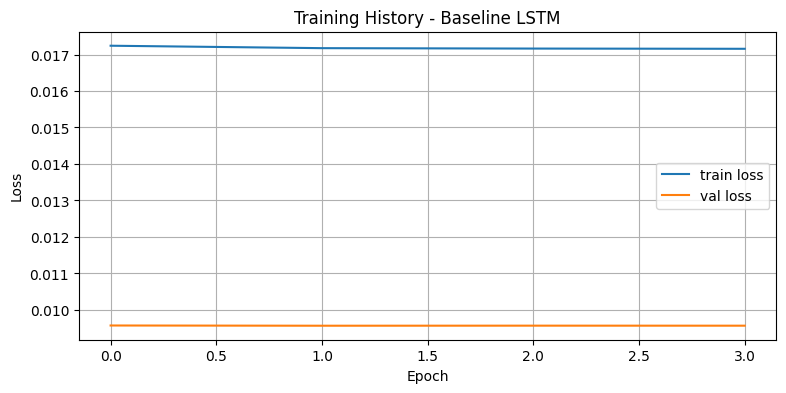

Training Seq2Seq LSTM Functional API
Epoch 001/13 | loss: 0.004700 | val_loss: 0.002651 | lr: 0.00100000
Epoch 002/13 | loss: 0.004446 | val_loss: 0.002648 | lr: 0.00100000
Epoch 003/13 | loss: 0.004437 | val_loss: 0.002668 | lr: 0.00100000
Reduce LR: 0.00100000 -> 0.00050000
Epoch 004/13 | loss: 0.004436 | val_loss: 0.002622 | lr: 0.00050000
Epoch 005/13 | loss: 0.004421 | val_loss: 0.002622 | lr: 0.00050000
Epoch 006/13 | loss: 0.004414 | val_loss: 0.002621 | lr: 0.00050000
Reduce LR: 0.00050000 -> 0.00025000
Epoch 007/13 | loss: 0.004411 | val_loss: 0.002622 | lr: 0.00025000
Early stopping aktif pada epoch 7. Best val_loss: 0.002622


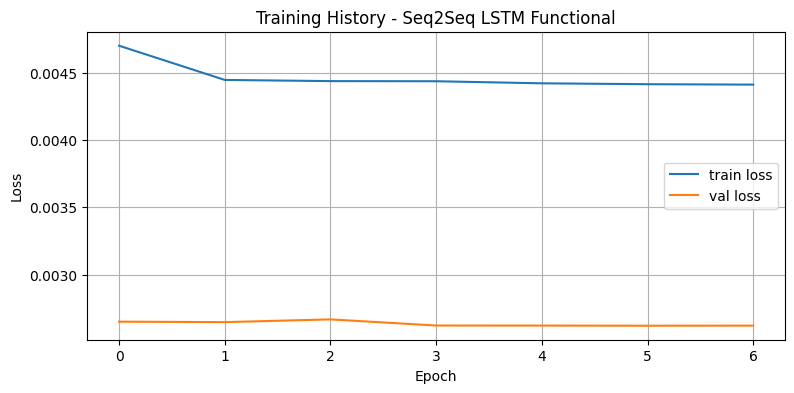

Training Seq2Seq LSTM Subclassing
Epoch 001/12 | loss: 0.003391 | val_loss: 0.001878 | lr: 0.00100000
Epoch 002/12 | loss: 0.003202 | val_loss: 0.001919 | lr: 0.00100000
Epoch 003/12 | loss: 0.003198 | val_loss: 0.002021 | lr: 0.00100000
Reduce LR: 0.00100000 -> 0.00050000
Early stopping aktif pada epoch 3. Best val_loss: 0.001878


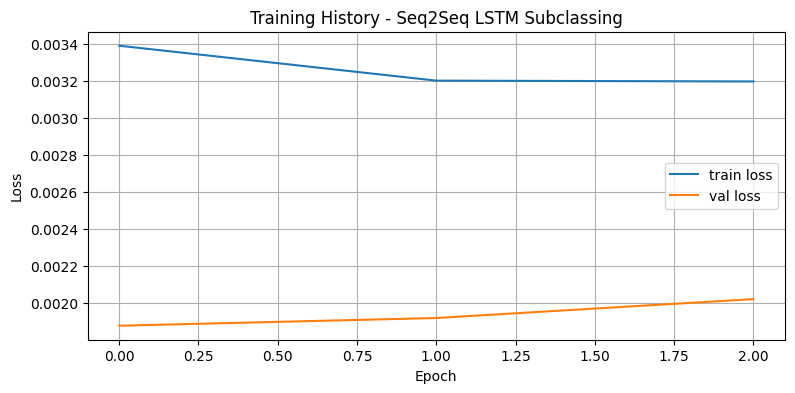

In [44]:
EPOCHS_BASELINE = 14
EPOCH_FUNCAPI = 13
EPOCHS_SUBCLASS = 12

print('Training Baseline LSTM')
history_baseline = train_custom_loop(baseline_model, train_ds_multi, val_ds_multi, epochs=EPOCHS_BASELINE, learning_rate=1e-3, loss_fn=weighted_horizon_mae, patience=3, model_name='Baseline LSTM')

print('Training Seq2Seq LSTM Functional API')
history_seq2seq = train_custom_loop(seq2seq_model, train_ds_multi, val_ds_multi, epochs=EPOCH_FUNCAPI, learning_rate=1e-3, loss_fn=weighted_horizon_mae, patience=3, model_name='Seq2Seq LSTM Functional')

print('Training Seq2Seq LSTM Subclassing')
history_subclass = train_custom_loop(subclass_seq2seq_model, train_ds_multi, val_ds_multi, epochs=EPOCHS_SUBCLASS, learning_rate=1e-3, loss_fn=custom_mae_loss, patience=2, model_name='Seq2Seq LSTM Subclassing')

## Evaluasi Seq2Seq model sebelum Inverse scaled

In [45]:
def evaluate_scaled_mae(model, dataset, model_name='model'):
    y_true_all, y_pred_all = [], []
    for x_batch, y_batch in dataset:
        model_input = prepare_model_input(model, x_batch)
        pred = model(model_input, training=False)
        y_true_all.append(y_batch.numpy())
        y_pred_all.append(pred.numpy())
    y_true_all = np.concatenate(y_true_all, axis=0)
    y_pred_all = np.concatenate(y_pred_all, axis=0)
    mae = mean_absolute_error(y_true_all.reshape(-1), y_pred_all.reshape(-1))
    mse = mean_squared_error(y_true_all.reshape(-1), y_pred_all.reshape(-1))
    print(f'{model_name} - Test MAE scaled : {mae:.6f}')
    print(f'{model_name} - Test MSE scaled : {mse:.6f}')
    return mae, mse, y_true_all, y_pred_all

mae_baseline, mse_baseline, y_true_baseline, y_pred_baseline = evaluate_scaled_mae(baseline_model, test_ds_multi, 'Baseline LSTM')
mae_seq2seq_tf, mse_seq2seq_tf, y_true_seq2seq_tf, y_pred_seq2seq_tf = evaluate_scaled_mae(seq2seq_model, test_ds_multi, 'Custom Seq2Seq LSTM Teacher Forcing')
mae_subclass, mse_subclass, y_true_subclass, y_pred_subclass = evaluate_scaled_mae(subclass_seq2seq_model, test_ds_multi, 'Seq2Seq LSTM Subclassing')

if mae_seq2seq_tf < 0.015:
    print('Target Advanced MAE < 0.015 tercapai untuk Custom Seq2Seq LSTM.')
else:
    print('MAE belum < 0.015. Naikkan EPOCHS_SEQ2SEQ menjadi 10 atau 15, lalu jalankan ulang training Seq2Seq.')

Baseline LSTM - Test MAE scaled : 0.005857
Baseline LSTM - Test MSE scaled : 0.000098
Custom Seq2Seq LSTM Teacher Forcing - Test MAE scaled : 0.001718
Custom Seq2Seq LSTM Teacher Forcing - Test MSE scaled : 0.000009
Seq2Seq LSTM Subclassing - Test MAE scaled : 0.001723
Seq2Seq LSTM Subclassing - Test MSE scaled : 0.000009
Target Advanced MAE < 0.015 tercapai untuk Custom Seq2Seq LSTM.


## Inferensi model autoregressive

In [46]:
def autoregressive_predict_seq2seq_full(model, encoder_input, horizon=24):
    decoder_input = np.zeros((1, horizon, 1), dtype=np.float32)
    decoder_input[0, 0, 0] = encoder_input[0, -1, target_index]
    preds = []
    for step in range(horizon):
        output = model([encoder_input, decoder_input], training=False).numpy()
        pred_step = output[0, step, 0]
        preds.append(pred_step)
        if step + 1 < horizon:
            decoder_input[0, step + 1, 0] = pred_step
    return np.array(preds).reshape(horizon, 1)

def inverse_close_values(close_scaled_values):
    close_scaled_values = np.asarray(close_scaled_values).reshape(-1)
    dummy = np.zeros((len(close_scaled_values), N_FEATURES))
    dummy[:, target_index] = close_scaled_values
    inversed = scaler.inverse_transform(dummy)
    return inversed[:, target_index]

def make_comparison_table(actual_scaled, pred_scaled, title):
    actual = inverse_close_values(actual_scaled)
    pred = inverse_close_values(pred_scaled)
    table = pd.DataFrame({'step': np.arange(1, len(actual) + 1), 'actual_close': actual, 'predicted_close': pred, 'selisih': actual - pred, 'abs_error': np.abs(actual - pred)})
    print(title)
    display(table)
    plt.figure(figsize=(12, 5))
    plt.plot(table['step'], table['actual_close'], marker='o', label='Actual Close')
    plt.plot(table['step'], table['predicted_close'], marker='o', label='Predicted Close')
    plt.title(title); plt.xlabel('Horizon Step ke-'); plt.ylabel('Close'); plt.legend(); plt.grid(True); plt.show()
    return table

Baseline LSTM: Aktual vs Prediksi 24 Jam


,step,actual_close,predicted_close,selisih,abs_error
0,1,26129.700224,26004.876842,124.823382,124.823382
1,2,26108.509580,26010.853838,97.655742,97.655742
2,3,25939.590316,26004.798818,-65.208502,65.208502
3,4,26015.430262,26007.334105,8.096157,8.096157
4,5,26050.699839,25993.432411,57.267428,57.267428
5,6,26034.180018,26004.841201,29.338817,29.338817
6,7,26097.740391,26002.120006,95.620384,95.620384
7,8,26105.599587,26013.171429,92.428158,92.428158
8,9,26196.009726,26017.120774,178.888951,178.888951
9,10,26132.000477,25996.290388,135.710089,135.710089


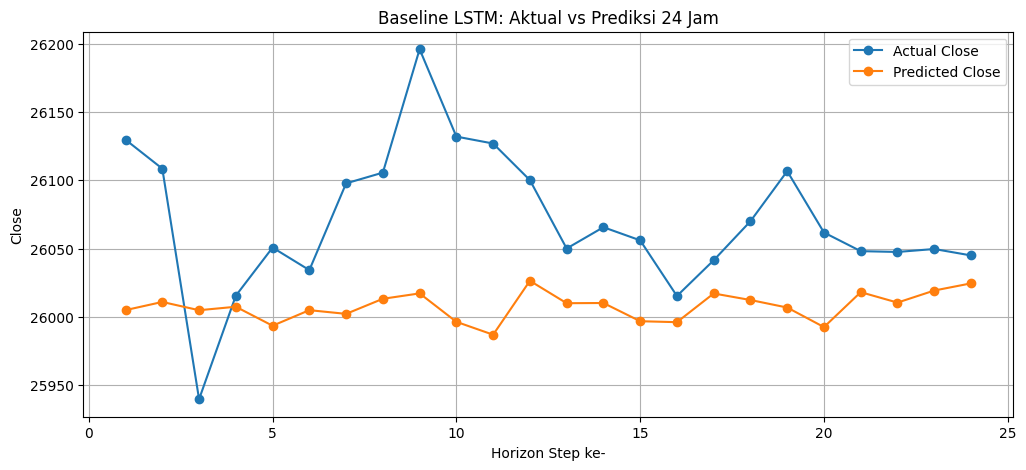

Seq2Seq LSTM Autoregressive: Aktual vs Prediksi 24 Jam


,step,actual_close,predicted_close,selisih,abs_error
0,1,26129.700224,25989.750850,139.949373,139.949373
1,2,26108.509580,25977.231427,131.278153,131.278153
2,3,25939.590316,25965.625169,-26.034853,26.034853
3,4,26015.430262,25958.255306,57.174956,57.174956
4,5,26050.699839,25954.511134,96.188705,96.188705
5,6,26034.180018,25951.151301,83.028717,83.028717
6,7,26097.740391,25948.232639,149.507751,149.507751
7,8,26105.599587,25945.909268,159.690319,159.690319
8,9,26196.009726,25944.119541,251.890185,251.890185
9,10,26132.000477,25942.937627,189.062849,189.062849


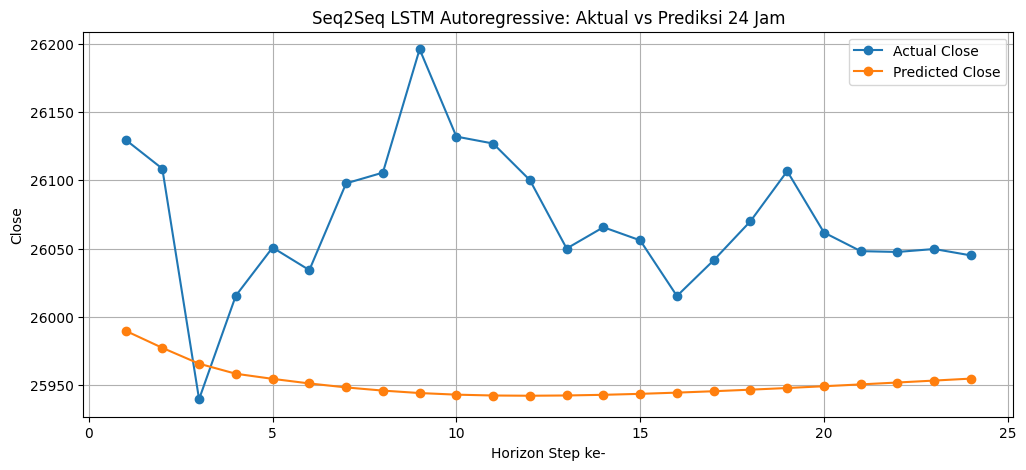

In [48]:
for (sample_enc, sample_dec), sample_y in test_ds_multi.take(1):
    sample_encoder_input = sample_enc[0:1]
    sample_target = sample_y[0].numpy()
    break

baseline_pred_scaled = baseline_model.predict(sample_encoder_input, verbose=0)[0]
baseline_table = make_comparison_table(sample_target, baseline_pred_scaled, 'Baseline LSTM: Aktual vs Prediksi 24 Jam')

seq2seq_pred_ar_scaled = autoregressive_predict_seq2seq_full(seq2seq_model, sample_encoder_input.numpy(), horizon=HORIZON)
seq2seq_table = make_comparison_table(sample_target, seq2seq_pred_ar_scaled, 'Seq2Seq LSTM Autoregressive: Aktual vs Prediksi 24 Jam')

## Evaluasi autoregressive pada data testing

In [50]:
def evaluate_autoregressive_on_samples(test_dataset, n_samples=10):
    actual_list, pred_list = [], []
    counter = 0
    for (enc_batch, dec_batch), y_batch in test_dataset:
        for i in range(enc_batch.shape[0]):
            enc_i = enc_batch[i:i+1].numpy()
            y_i = y_batch[i].numpy()
            pred_i = autoregressive_predict_seq2seq_full(seq2seq_model, enc_i, horizon=HORIZON)
            actual_list.append(y_i.reshape(-1)); pred_list.append(pred_i.reshape(-1)); counter += 1
            if counter >= n_samples:
                break
        if counter >= n_samples:
            break
    actual_arr = np.array(actual_list)
    pred_arr = np.array(pred_list)
    mae_ar = mean_absolute_error(actual_arr.reshape(-1), pred_arr.reshape(-1))
    print(f'Seq2Seq Autoregressive MAE scaled pada {counter} sample test: {mae_ar:.6f}')
    return mae_ar, actual_arr, pred_arr

mae_seq2seq_ar, actual_ar, pred_ar = evaluate_autoregressive_on_samples(test_ds_multi, n_samples=10)

Seq2Seq Autoregressive MAE scaled pada 10 sample test: 0.002987


## Save Model .keras

In [51]:
baseline_model.save('model_baseline_LSTM.keras')
seq2seq_model.save('model_seq2seq_LSTM.keras')

if mae_seq2seq_tf <= mae_baseline:
    seq2seq_model.save('best_model_seq2seq_LSTM.keras')
    print('Best model: Seq2Seq LSTM')
else:
    baseline_model.save('best_model_seq2seq_LSTM.keras')
    print('Best model: Baseline LSTM')

print('File model berhasil dibuat:')
print('- model_baseline_LSTM.keras')
print('- model_seq2seq_LSTM.keras')
print('- best_model_seq2seq_LSTM.keras')

Best model: Seq2Seq LSTM
File model berhasil dibuat:
- model_baseline_LSTM.keras
- model_seq2seq_LSTM.keras
- best_model_seq2seq_LSTM.keras
